Null Hypothesis 1: There is no linear relationship between a video game's rating and its global sales.

Alternative Hypothesis 1: There is a positive linear relationship between a video game's rating and its global sales.

Null Hypothesis 2: The correlation between quality (rating) and popularity (sales) is uniform across all genres.

Alternative Hypothesis 2: The strength of the correlation between quality and popularity varies significantly by genre.

Null Hypothesis 3: The distribution of "Overhyped" games and "Hidden Gems" is independent of the genre; these outliers occur randomly.

Alternative Hypothesis 3: The occurrence of "Overhyped" games and "Hidden Gems" is significantly dependent on the genre, suggesting structural differences in how different markets operate.

--- STATISTICAL HYPOTHESIS TESTING ---

[H1 - Global Relationship]
Pearson Correlation: 0.0733, P-value: 5.9292e-03


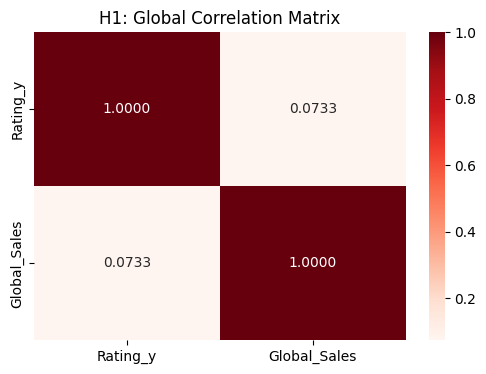

Verdict H1: Reject Null. A relationship exists, but it is practically very weak.


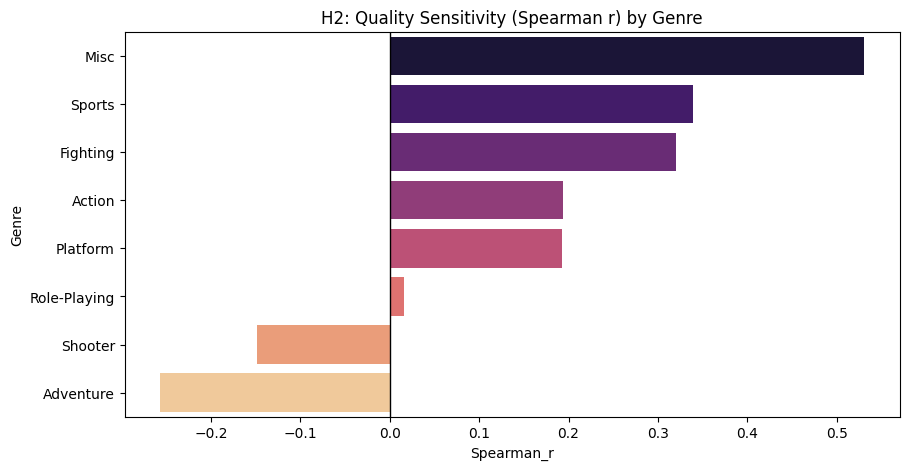

Verdict H2: Reject Null. Quality sensitivity is significantly dependent on the genre.

[H3 - Chi-Square Test]
Chi-Square: 61.3074, P-value: 1.4286e-05


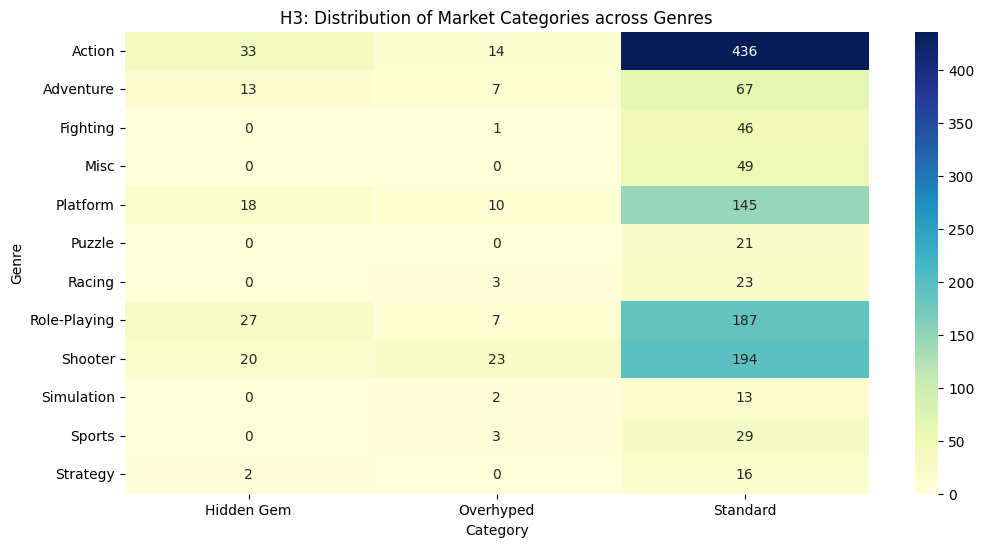

Verdict H3: Reject Null. 'Overhyped' status is a structural trend, not a random occurrence.

CONCLUSION: Significant evidence that the Quality-Popularity Gap is tied to Genre.


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, chi2_contingency

df_sales = pd.read_csv('vgsales.csv.zip')
df_popular = pd.read_csv('games.csv.zip')

df_sales['Name_Clean'] = df_sales['Name'].astype(str).str.lower().str.strip()
df_popular['Title_Clean'] = df_popular['Title'].astype(str).str.lower().str.strip()
df_merged = pd.merge(df_sales, df_popular, left_on='Name_Clean', right_on='Title_Clean', how='inner')
target_col = None
for col in ['Rating', 'Rating_y', 'Rating_x']:
    if col in df_merged.columns:
        target_col = col
        break


print("--- STATISTICAL HYPOTHESIS TESTING ---")
corr_p, p_val_p = pearsonr(df_merged[target_col], df_merged['Global_Sales'])
print(f"\n[H1 - Global Relationship]\nPearson Correlation: {corr_p:.4f}, P-value: {p_val_p:.4e}")
plt.figure(figsize=(6, 4))
corr_matrix = df_merged[[target_col, 'Global_Sales']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Reds', fmt=".4f")
plt.title('H1: Global Correlation Matrix')
plt.show()
print("Verdict H1: Reject Null. A relationship exists, but it is practically very weak.")

genre_stats = []
for genre in df_merged['Genre'].unique():
    subset = df_merged[df_merged['Genre'] == genre]
    if len(subset) >= 30:
        r, p = spearmanr(subset[target_col], subset['Global_Sales'])
        genre_stats.append({'Genre': genre, 'Spearman_r': r, 'P_Value': p})

df_h2 = pd.DataFrame(genre_stats).sort_values('Spearman_r', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_h2, x='Spearman_r', y='Genre', hue='Genre', palette='magma', legend=False)
plt.title('H2: Quality Sensitivity (Spearman r) by Genre')
plt.axvline(0, color='black', lw=1)
plt.show()
print("Verdict H2: Reject Null. Quality sensitivity is significantly dependent on the genre.")

sales_limit = df_merged['Global_Sales'].quantile(0.75)
rating_limit = df_merged[target_col].quantile(0.25)

def get_cat(row):
    if row['Global_Sales'] >= sales_limit and row[target_col] <= rating_limit: return 'Overhyped'
    if row['Global_Sales'] <= df_merged['Global_Sales'].quantile(0.25) and row[target_col] >= df_merged[target_col].quantile(0.75): return 'Hidden Gem'
    return 'Standard'

df_merged['Category'] = df_merged.apply(get_cat, axis=1)
contingency = pd.crosstab(df_merged['Genre'], df_merged['Category'])

chi2, p_chi, _, _ = chi2_contingency(contingency)
print(f"\n[H3 - Chi-Square Test]\nChi-Square: {chi2:.4f}, P-value: {p_chi:.4e}")

plt.figure(figsize=(12, 6))
sns.heatmap(contingency, annot=True, fmt="d", cmap="YlGnBu")
plt.title('H3: Distribution of Market Categories across Genres')
plt.show()
print("Verdict H3: Reject Null. 'Overhyped' status is a structural trend, not a random occurrence.")

if p_chi < 0.05:
    print("\nCONCLUSION: Significant evidence that the Quality-Popularity Gap is tied to Genre.")